# Edge Function Comparison: SG-KAN(SWIM) vs. HKAN (TF3)

Fits both models at their **best TF3 configuration** (Tables `tab:sgkan-best-config` and `tab:hkan-config`), then plots one fitted edge function from each, side by side, over the same input range. The SG-KAN panel shades the actual `[lo, hi]` interval the edge was fit on.

## Step 0: Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

sys.path.append(os.path.abspath("."))  # adjust if sgkan/hkan/utils live elsewhere

from sgkan import sgkan_model
from sgkan.sgkan_model import apply_kernel
import utils
from hkan.hkan import Tanh, Identity


/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load TF3 dataset

In [2]:
def load_dataset(dataset_prefix: str):
    DATA_DIR = os.path.join(os.getcwd(), "data")
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    print("x_train shape:", x_train.shape)
    return x_train, x_test, y_train, y_test

tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")


x_train shape: (5000, 2)


## Step 2: Fit SG-KAN(SWIM) at its best TF3 configuration

From Table `tab:sgkan-best-config`: `layer_width=1000,1`, `num_inducing=10`, `alpha_edge=1.0`, `alpha_neuron=0`, `kernel_type=matern`.

In [3]:
best_tf3_sgkan_configs = [
    dict(layer_width=1000, pair_selection_strategy="swim", num_inducing=10,
         sigma_scale=1, alpha_edge=1.0, alpha_neuron=0.0, seed=0,
         kernel_type="matern", max_local_points=1000),
    dict(layer_width=1, pair_selection_strategy="swim", num_inducing=10,
         sigma_scale=1, alpha_edge=1.0, alpha_neuron=0.0, seed=0,
         kernel_type="matern", max_local_points=1000),
]

best_tf3_sgkan_model = sgkan_model.SGKANModel(best_tf3_sgkan_configs).fit(tf3_x_train, tf3_y_train)

tf3_sgkan_layer1_neurons = best_tf3_sgkan_model.neurons_per_layer[0]
print(f"First layer: {len(tf3_sgkan_layer1_neurons)} hidden units, "
      f"{len(tf3_sgkan_layer1_neurons[0]['edge_params'])} edges each")


[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 934, 'interval_capped': 1063, 'knn_fallback': 3}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 782, 'interval': 216, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 7.0869s
First layer: 1000 hidden units, 2 edges each


## Step 3: Fit HKAN at its best TF3 configuration

From Table `tab:hkan-config`: `L=2`, `n=924`, basis types Tanh (layer 0) / Identity (layer 1), $\sigma=50$, $m=39$, random centers, $\lambda_\phi=0.001$.

In [4]:
tf3_hkan_layer_configs = [
    dict(layer=0, n_vars_out=924, n_basis=39, centers="random",
         basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.001)),
    dict(layer=1, n_vars_out=1, n_basis=39, centers="random",
         basis_fn=Identity(), expanding_base_regressor=Ridge(alpha=0.001)),
]

tf3_hkan_model = utils.build_hkan_model_from_configs(tf3_hkan_layer_configs)
utils.fit_hkan(tf3_hkan_model, tf3_x_train, tf3_y_train)


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]


✓ HKAN training completed in 13.3835 seconds


## Step 4: Edge-function extraction and plotting helpers

In [5]:
def get_sgkan_edge(neurons, q, p):
    """Pull the fitted edge parameters for hidden unit q, dimension p
    out of an SG-KAN layer's `neurons` list."""
    neuron = neurons[q]
    edge = neuron["edge_params"][p]
    return dict(
        z_p=edge["z_p"], l_p=edge["l_p"], w_p=edge["w_p"], b_p=edge["b_p"],
        lo=edge["lo"], hi=edge["hi"],
        kernel_type=neuron["kernel_type"], period=neuron["period"],
    )


def get_hkan_edge(hkan_model, layer_idx, q, p):
    """Pull the fitted basis centers, basis function, and per-edge
    regressor for hidden unit q, dimension p out of a fitted HKAN
    Pipeline's ExpandingLayer at the given layer index."""
    expanding_layer = hkan_model.named_steps[f"expanding_layer_{layer_idx}"]
    centers = expanding_layer.centers_arr_[q, p, :]
    basis_fn = expanding_layer.basis_fn
    reg = next(r for (qq, pp, r) in expanding_layer.models_ if qq == q and pp == p)
    return dict(centers=centers, basis_fn=basis_fn, reg=reg)


def plot_edge_comparison(
    sgkan_neurons, sgkan_X_train, sgkan_q, sgkan_p,
    hkan_model, hkan_X_train, hkan_q, hkan_p, hkan_layer_idx=0,
    dataset_name="TF3", n_points=400, save_path=None,
):
    """Plot the SG-KAN and HKAN edge functions for the given (q, p) pairs
    side by side, both evaluated over the full range of dimension p."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

    # --- SG-KAN edge ---
    sg = get_sgkan_edge(sgkan_neurons, sgkan_q, sgkan_p)
    x_min, x_max = sgkan_X_train[:, sgkan_p].min(), sgkan_X_train[:, sgkan_p].max()
    x_dense = np.linspace(x_min, x_max, n_points)
    sg_curve = apply_kernel(
        x_dense, sg["z_p"], sg["l_p"], kernel_type=sg["kernel_type"], period=sg["period"]
    ) @ sg["w_p"] + sg["b_p"]

    ax = axes[0]
    ax.axvspan(sg["lo"], sg["hi"], color="orange", alpha=0.15,
               label="fitted interval $[\\mathrm{lo}_{q,p}, \\mathrm{hi}_{q,p}]$")
    ax.plot(x_dense, sg_curve, color="steelblue", lw=2, label=f"$\\phi_{{{sgkan_q},{sgkan_p}}}(x)$")
    ax.scatter(sg["z_p"], np.zeros_like(sg["z_p"]), color="red", marker="^", s=40,
               label="inducing points $\\mathbf{z}_{q,p}$")
    ax.set_xlabel(f"$x_{{{sgkan_p}}}$")
    ax.set_ylabel("edge output")
    ax.set_title(f"SG-KAN - neuron $q={sgkan_q}$, dim $p={sgkan_p}$")
    ax.legend(fontsize=11, loc="best")

    # --- HKAN edge ---
    hk = get_hkan_edge(hkan_model, hkan_layer_idx, hkan_q, hkan_p)
    x_min_h, x_max_h = hkan_X_train[:, hkan_p].min(), hkan_X_train[:, hkan_p].max()
    x_dense_h = np.linspace(x_min_h, x_max_h, n_points)
    features = hk["basis_fn"](x_dense_h.reshape(-1, 1) - hk["centers"].reshape(1, -1))
    hk_curve = hk["reg"].predict(features)

    ax = axes[1]
    ax.plot(x_dense_h, hk_curve, color="steelblue", lw=2, label=f"$\\phi_{{{hkan_q},{hkan_p}}}(x)$")
    ax.scatter(hk["centers"], np.zeros_like(hk["centers"]), color="red", marker="^", s=40,
               label="basis centers $\\mu_{q,p,r}$")
    ax.set_xlabel(f"$x_{{{hkan_p}}}$")
    ax.set_ylabel("edge output")
    ax.set_title(f"HKAN - neuron $q={hkan_q}$, dim $p={hkan_p}$")
    ax.legend(fontsize=11, loc="best")

    fig.suptitle(f"{dataset_name} - Edge Function Coverage: SG-KAN (SWIM) vs. HKAN", fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"saved to {save_path}")

    plt.show()
    return fig, axes


## Step 5: Run the comparison

Pick any `sgkan_q` in `range(1000)` and `hkan_q` in `range(924)` -- try a few different values if the first pair doesn't look interesting.

saved to static/tf3_edge_coverage_comparison.png


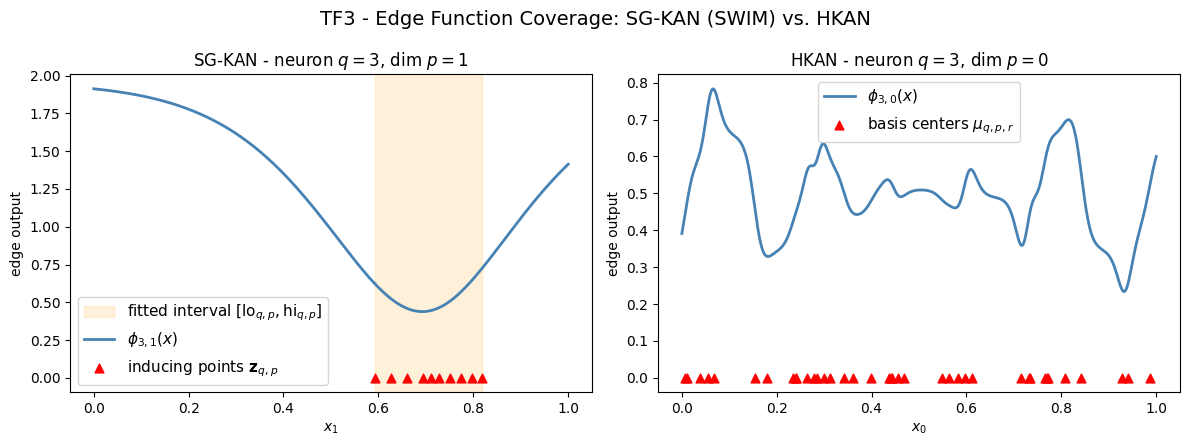

In [6]:
fig, axes = plot_edge_comparison(
    sgkan_neurons=tf3_sgkan_layer1_neurons,
    sgkan_X_train=tf3_x_train,
    sgkan_q=3, sgkan_p=1,
    hkan_model=tf3_hkan_model,
    hkan_X_train=tf3_x_train,
    hkan_q=3, hkan_p=0,
    hkan_layer_idx=0,
    dataset_name="TF3",
    save_path="static/tf3_edge_coverage_comparison.png",
)


In [7]:
edge = tf3_sgkan_layer1_neurons[3]["edge_params"][1]
print(edge["lo"], edge["hi"], edge["l_p"])

0.592338566664636 0.819226642658779 0.22688807599414296
